# Polyvore Outfit Recovery Eval

Tests how well each pipeline variant recovers known-good Polyvore outfit combinations.

**Setup:** For each eval question, the pipeline gets a mini-wardrobe containing:
- Items from a real Polyvore outfit — the ground truth
- Random distractor items from other outfits (same categories)

**Metric:** Recall@k — does any top-k recommendation correctly identify all ground truth items?

**Pipelines tested:**
- **V1** — Grid → Vision LLM (one-shot visual, no metadata)
- **V4** — FashionCLIP combined embeddings + LLM selection
- **V5** — Pure FashionCLIP, no LLM

Run **Sections 1–6** once per session to load data and models.  
Then run **Section 7** (eval runner) and **Section 8** (results).

## 1. Imports and paths

In [3]:
from __future__ import annotations

import io
import itertools
import json
import math
import os
import random
import re
import time
from collections import defaultdict
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from dotenv import load_dotenv
from huggingface_hub import hf_hub_download
from openai import OpenAI
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

load_dotenv()

def project_root() -> Path:
    here = Path.cwd().resolve()
    if here.name == 'notebooks' and (here / 'images').is_dir():
        return here
    if (here / 'notebooks').is_dir():
        return here / 'notebooks'
    return here

ROOT      = project_root()
EVAL_DIR  = ROOT / 'eval_polyvore'
IMG_DIR   = EVAL_DIR / 'images'
RES_DIR   = EVAL_DIR / 'results'
for d in [EVAL_DIR, IMG_DIR, RES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'ROOT: {ROOT}')

ROOT: /Users/mohitjoshi/Projects/fashion-app/notebooks


## 2. Config

In [17]:
# --- Eval scale ---
N_EVAL_OUTFITS        = 50    # set to 200 for full eval
N_DISTRACTORS_PER_CAT = 3    # random items added per category
RANDOM_SEED           = 42
QUERY                 = 'recommend a stylish outfit'

# --- LLM ---
PROVIDER   = 'openrouter'   # 'openrouter' or 'openai'
LLM_MODEL  = 'google/gemini-3.1-flash-lite-preview'

# --- Rate limiting ---
CALL_DELAY_S  = 2.0   # seconds between LLM calls; increase if still hitting limits
MAX_RETRIES   = 5     # retries on 429 / rate-limit errors
RETRY_BASE_S  = 5.0   # backoff base in seconds (doubles each retry)

# --- FashionCLIP ---
FASHIONCLIP_LOCAL  = ROOT / 'models' / 'fashion-clip'
IMAGE_WEIGHT       = 0.5   # alpha for combined embeddings (V4)
CANDIDATES_PER_CAT = 3     # top-k per category before LLM (V4)

## 3. Load and filter Polyvore outfits

In [3]:
CLOTHING_CATS = {'tops', 'bottoms', 'outerwear'}
DATASET_ID    = 'mvasil/polyvore-outfits'

print('Downloading Polyvore metadata...')
meta_path = hf_hub_download(DATASET_ID, 'polyvore_item_metadata.json', repo_type='dataset')
with open(meta_path) as f:
    item_meta = json.load(f)   # {item_id: {url_name, semantic_category, ...}}

train_path = hf_hub_download(DATASET_ID, 'nondisjoint/train.json', repo_type='dataset')
with open(train_path) as f:
    raw_outfits = json.load(f)

print(f'Raw outfits: {len(raw_outfits)}  |  Items in metadata: {len(item_meta)}')

# Keep outfits with at least top + bottom (clothing items only)
valid_outfits: list[dict] = []
for outfit in raw_outfits:
    cats: dict[str, str] = {}
    for item in outfit['items']:
        iid = item['item_id']
        cat = item_meta.get(iid, {}).get('semantic_category', '')
        if cat in CLOTHING_CATS and cat not in cats:
            cats[cat] = iid
    if 'tops' in cats and 'bottoms' in cats:
        valid_outfits.append({'set_id': outfit['set_id'], 'items': cats})

print(f'Valid outfits (tops+bottoms): {len(valid_outfits)}')

# Category distribution
from collections import Counter
dist = Counter(tuple(sorted(o['items'])) for o in valid_outfits)
for combo, n in dist.most_common():
    print(f'  {combo}: {n}')

Raw outfits: 53306  |  Items in metadata: 251008
Valid outfits (tops+bottoms): 29199
  ('bottoms', 'tops'): 18894
  ('bottoms', 'outerwear', 'tops'): 10305


## 4. Sample eval set and build mini-wardrobes

Each mini-wardrobe = ground-truth items + N random distractors per category (from other outfits).  
The pipeline must pick the right item per category from a wardrobe it hasn't seen before.

In [4]:
random.seed(RANDOM_SEED)

eval_outfits = random.sample(valid_outfits, min(N_EVAL_OUTFITS, len(valid_outfits)))
eval_ids     = {o['set_id'] for o in eval_outfits}

# Build per-category distractor pool from non-eval outfits
distractor_pool: dict[str, list[str]] = defaultdict(list)
for outfit in valid_outfits:
    if outfit['set_id'] not in eval_ids:
        for cat, iid in outfit['items'].items():
            distractor_pool[cat].append(iid)

def build_mini_wardrobe(outfit: dict) -> list[dict]:
    """Ground-truth items + N random distractors per category."""
    items = [{'item_id': iid, 'category': cat}
             for cat, iid in outfit['items'].items()]
    gt_ids = set(outfit['items'].values())
    for cat in outfit['items']:
        pool = [x for x in distractor_pool[cat] if x not in gt_ids]
        k    = min(N_DISTRACTORS_PER_CAT, len(pool))
        items.extend({'item_id': iid, 'category': cat}
                     for iid in random.sample(pool, k))
    random.shuffle(items)
    return items

eval_dataset = [
    {
        'set_id':       o['set_id'],
        'ground_truth': o['items'],           # {category: item_id}
        'wardrobe':     build_mini_wardrobe(o) # [{item_id, category}]
    }
    for o in eval_outfits
]

with open(EVAL_DIR / 'eval_dataset.json', 'w') as f:
    json.dump(eval_dataset, f, indent=2)

print(f'Eval questions: {len(eval_dataset)}')
print(f'Sample wardrobe size: {len(eval_dataset[0]["wardrobe"])} items')
print(f'Sample ground truth: {eval_dataset[0]["ground_truth"]}')

Eval questions: 50
Sample wardrobe size: 12 items
Sample ground truth: {'tops': '182455006', 'bottoms': '179904105', 'outerwear': '191688466'}


## 5. Download and cache item images

Streams through the Polyvore HuggingFace dataset and saves only the images needed for eval.  
Re-running skips already-cached images.

In [5]:
needed_ids = {item['item_id'] for q in eval_dataset for item in q['wardrobe']}
cached_ids = {p.stem for p in IMG_DIR.glob('*.jpg')}
to_fetch   = needed_ids - cached_ids

print(f'Need: {len(needed_ids)}  |  Cached: {len(cached_ids)}  |  To download: {len(to_fetch)}')

def save_hf_image(img_field, path: Path) -> bool:
    """Save a HuggingFace image field (dict or PIL) to disk."""
    try:
        if isinstance(img_field, dict) and img_field.get('bytes'):
            img = Image.open(io.BytesIO(img_field['bytes'])).convert('RGB')
        elif hasattr(img_field, 'convert'):
            img = img_field.convert('RGB')
        else:
            return False
        img.thumbnail((224, 224))
        img.save(path, 'JPEG')
        return True
    except Exception:
        return False

if to_fetch:
    saved, missing = 0, 0
    for split in ['train', 'validation', 'test']:
        if not to_fetch:
            break
        ds = load_dataset(DATASET_ID, 'nondisjoint', split=split, streaming=True)
        for row in ds:
            iid = row['item_id']
            if iid in to_fetch:
                ok = save_hf_image(row['image'], IMG_DIR / f'{iid}.jpg')
                to_fetch.discard(iid)
                if ok:
                    saved += 1
                else:
                    missing += 1
                if (saved + missing) % 100 == 0:
                    print(f'  saved={saved}  missing={missing}  remaining={len(to_fetch)}')
    print(f'Done — saved={saved}  could_not_save={missing}  not_found={len(to_fetch)}')
else:
    print('All images already cached.')

Need: 465  |  Cached: 0  |  To download: 465
  saved=100  missing=0  remaining=365
  saved=200  missing=0  remaining=265
  saved=300  missing=0  remaining=165
  saved=400  missing=0  remaining=65
Done — saved=465  could_not_save=0  not_found=0


## 5b. LLM metadata extraction (one-time, cached)

Extracts rich metadata (colors, formality, style tags, pairing hints) for every eval item via vision LLM.  
Saved per-item to `eval_polyvore/metadata/{item_id}.json` — **skips already-cached items**.

- **Optional but recommended** — improves V4 text embeddings beyond Polyvore's sparse `url_name`  
- **Required** for V2 (metadata → text LLM), which is not yet included in this notebook  
- Uncomment `run_metadata_extraction(...)` to run; comment it back out after the first run

In [32]:
META_DIR = EVAL_DIR / 'metadata'
META_DIR.mkdir(exist_ok=True)

EXTRACTION_SYSTEM = """\
You are a fashion metadata extractor. Given a clothing image, return ONLY valid JSON:
{
  "type": "<specific garment type>",
  "category": "<tops|bottoms|outerwear|dress|shoes|bag|other>",
  "colors": {"primary": "<color>", "all": ["<color>", ...]},
  "visual_attributes": {"pattern": "<solid|striped|floral|..>", "material": "<cotton|silk|..>"},
  "shape_fit": {"fit": "<slim|relaxed|oversized>", "silhouette": "<..>"},
  "style": {
    "formality": <0.0-1.0>,
    "style_tags": ["<tag>", ...],
    "occasion_suitability": ["casual"|"office"|"party"|"formal"|...]
  },
  "seasonality": {"season": ["spring"|"summer"|"autumn"|"winter"]},
  "pairing_hints": {"goes_well_with": ["<desc>"], "avoid_with": ["<desc>"]}
}"""

def extract_item_metadata(item_id: str, client: OpenAI, model: str) -> dict | None:
    """Call vision LLM to extract rich metadata for one item. Returns None on failure."""
    img_path = IMG_DIR / f'{item_id}.jpg'
    if not img_path.is_file():
        return None
    import base64
    b64 = base64.standard_b64encode(img_path.read_bytes()).decode()
    try:
        resp = client.chat.completions.create(
            model=model,
            messages=[
                {'role': 'system', 'content': EXTRACTION_SYSTEM},
                {'role': 'user', 'content': [
                    {'type': 'text',      'text': 'Extract metadata for this garment.'},
                    {'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{b64}'}},
                ]},
            ],
            temperature=0.1,
        )
        raw = resp.choices[0].message.content or '{}'
        raw = re.sub(r'^```[\w]*\n?', '', raw.strip())
        raw = re.sub(r'\n?```$',      '', raw.strip())
        result = json.loads(raw)
        result['item_id'] = item_id
        return result
    except Exception as e:
        print(f'  [{item_id}] error: {e}')
        return None

def run_metadata_extraction(client: OpenAI, model: str):
    """
    Extract and cache metadata for all images in IMG_DIR not yet processed.
    Scans IMG_DIR directly — safe to interrupt and rerun, no dependency on eval_dataset.
    """
    all_ids = {p.stem for p in IMG_DIR.glob('*.jpg')}
    cached  = {p.stem for p in META_DIR.glob('*.json')}
    to_run  = sorted(all_ids - cached)
    print(f'Images in IMG_DIR: {len(all_ids)}  |  Cached: {len(cached)}  |  To extract: {len(to_run)}')
    if not to_run:
        print('All metadata cached.')
        return
    for i, iid in enumerate(to_run):
        meta = extract_item_metadata(iid, client, model)
        if meta:
            (META_DIR / f'{iid}.json').write_text(json.dumps(meta, indent=2))
        if (i + 1) % 25 == 0:
            print(f'  {i+1}/{len(to_run)} done')
    print('Metadata extraction complete.')

# Uncomment to run — one LLM call per item, run once then leave commented.
run_metadata_extraction(llm_client, LLM_MODEL)

# Always load whatever is cached (empty dict if extraction hasn't been run yet)
extracted_meta: dict[str, dict] = {}
for p in META_DIR.glob('*.json'):
    try:
        extracted_meta[p.stem] = json.loads(p.read_text())
    except Exception:
        pass
print(f'Loaded {len(extracted_meta)} extracted metadata records  '
      f'(run run_metadata_extraction(llm_client, LLM_MODEL) to populate)')

Images in IMG_DIR: 465  |  Cached: 465  |  To extract: 0
All metadata cached.
Loaded 465 extracted metadata records  (run run_metadata_extraction(llm_client, LLM_MODEL) to populate)


## 6. FashionCLIP model and embedding helpers

In [19]:
def load_fashionclip(local_dir: Path = FASHIONCLIP_LOCAL):
    device = torch.device(
        'mps'  if torch.backends.mps.is_available()  else
        'cuda' if torch.cuda.is_available()           else 'cpu'
    )
    source = str(local_dir) if local_dir.exists() else 'patrickjohncyh/fashion-clip'
    print(f'Loading FashionCLIP from {source} on {device} ...')
    processor = CLIPProcessor.from_pretrained(source)
    model     = CLIPModel.from_pretrained(source).to(device).eval()
    return model, processor, device

def _img_feats(model, pv):  return model.visual_projection(model.vision_model(pixel_values=pv).pooler_output)
def _txt_feats(model, ids, mask): return model.text_projection(model.text_model(input_ids=ids, attention_mask=mask).pooler_output)

CLIP_MAX_TOKENS = 77  # hard limit of CLIP's text encoder

def embed_images(paths: list[Path], model, processor, device, batch=16) -> np.ndarray:
    vecs = []
    for i in range(0, len(paths), batch):
        imgs = [Image.open(p).convert('RGB') for p in paths[i:i+batch]]
        pv   = processor(images=imgs, return_tensors='pt')['pixel_values'].to(device)
        with torch.no_grad():
            f = _img_feats(model, pv)
        vecs.append((f / f.norm(dim=-1, keepdim=True)).cpu().float().numpy())
    return np.concatenate(vecs)

def embed_texts(texts: list[str], model, processor, device, batch=32) -> np.ndarray:
    vecs = []
    for i in range(0, len(texts), batch):
        enc  = processor(text=texts[i:i+batch], return_tensors='pt',
                         padding=True, truncation=True, max_length=CLIP_MAX_TOKENS)
        ids  = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
        with torch.no_grad():
            f = _txt_feats(model, ids, mask)
        vecs.append((f / f.norm(dim=-1, keepdim=True)).cpu().float().numpy())
    return np.concatenate(vecs)

clip_model, clip_proc, clip_device = load_fashionclip()
print('FashionCLIP ready.')

Loading FashionCLIP from /Users/mohitjoshi/Projects/fashion-app/notebooks/models/fashion-clip on mps ...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

FashionCLIP ready.


## 6b. Embedding cache (build once, reuse across all pipeline runs)

Computes FashionCLIP embeddings for every eval item and saves to `eval_polyvore/embeddings.npz`.  
V4 and V5 look up from this dict instead of recomputing per question.  
Re-run with `force=True` only if `IMAGE_WEIGHT` changes or `extracted_meta` is newly populated.

In [ ]:
META_DIR = EVAL_DIR / 'metadata'
EMB_CACHE_PATH = EVAL_DIR / 'embeddings.npz'

def build_eval_embeddings(alpha: float = IMAGE_WEIGHT, force: bool = False) -> dict[str, np.ndarray]:
    """
    Embed all images in IMG_DIR. Fully self-contained — loads metadata from disk/HF cache
    so it works even if earlier cells haven't been run in this session.
    Re-run with force=True if IMAGE_WEIGHT changes or extracted_meta is newly populated.
    """
    if not force and EMB_CACHE_PATH.is_file():
        data = np.load(EMB_CACHE_PATH, allow_pickle=False)
        ids  = data['ids'].tolist()
        embs = data['embeddings']
        print(f'Loaded embedding cache: {len(ids)} items  ({EMB_CACHE_PATH})')
        return dict(zip(ids, embs))

    img_paths = sorted(IMG_DIR.glob('*.jpg'))
    if not img_paths:
        print(f'No images found in {IMG_DIR} — run Section 5 first.')
        return {}
    ids_p   = [p.stem for p in img_paths]
    paths_p = list(img_paths)

    # Load metadata dicts — tolerate missing session variables, fall back to disk
    try:
        _extracted = extracted_meta
    except NameError:
        _extracted = {}
        for p in META_DIR.glob('*.json'):
            try:
                _extracted[p.stem] = json.loads(p.read_text())
            except Exception:
                pass

    try:
        _item_meta = item_meta
    except NameError:
        try:
            from huggingface_hub import hf_hub_download as _hf_dl
            _mp = _hf_dl('mvasil/polyvore-outfits', 'polyvore_item_metadata.json', repo_type='dataset')
            _item_meta = json.loads(Path(_mp).read_text())
        except Exception:
            _item_meta = {}

    def _text(iid: str) -> str:
        if iid in _extracted:
            m = _extracted[iid]
            colors   = ', '.join(m.get('colors', {}).get('all', []))
            pattern  = m.get('visual_attributes', {}).get('pattern', '')
            material = m.get('visual_attributes', {}).get('material', '')
            style    = ', '.join(m.get('style', {}).get('style_tags', []))
            occasion = ', '.join(m.get('style', {}).get('occasion_suitability', []))
            seasons  = ', '.join(m.get('seasonality', {}).get('season', []))
            return (f"type: {m.get('type','')}; colors: {colors}; pattern: {pattern}; "
                    f"material: {material}; style: {style}; occasion: {occasion}; season: {seasons}")
        pm = _item_meta.get(iid, {})
        return f"type: {pm.get('semantic_category','')}; {pm.get('url_name','')}".strip('; ')

    # Warn if metadata extraction hasn't been run — V4 quality degrades significantly without it
    coverage = sum(1 for iid in ids_p if iid in _extracted) / len(ids_p) if ids_p else 0
    if coverage < 0.5:
        print(f'WARNING: extracted_meta covers only {coverage:.0%} of items.')
        print('  Run Section 5b (run_metadata_extraction) before building embeddings for best V4 results.')
    else:
        print(f'Metadata coverage: {coverage:.0%} of items have extracted metadata.')

    print(f'Computing embeddings for {len(ids_p)} items (alpha={alpha}) ...')
    texts    = [_text(iid) for iid in ids_p]
    img_vecs = embed_images(paths_p, clip_model, clip_proc, clip_device)
    txt_vecs = embed_texts(texts,    clip_model, clip_proc, clip_device)
    combined = alpha * img_vecs + (1 - alpha) * txt_vecs
    norms    = np.linalg.norm(combined, axis=-1, keepdims=True)
    combined = (combined / np.where(norms > 0, norms, 1)).astype(np.float32)

    np.savez(EMB_CACHE_PATH, ids=np.array(ids_p), embeddings=combined)
    print(f'Saved -> {EMB_CACHE_PATH}  (shape={combined.shape})')
    return dict(zip(ids_p, combined))

emb_cache = build_eval_embeddings()
print(f'emb_cache ready: {len(emb_cache)} items')

Metadata coverage: 100% of items have extracted metadata.
Computing embeddings for 465 items (alpha=0.5) ...
Saved -> /Users/mohitjoshi/Projects/fashion-app/notebooks/eval_polyvore/embeddings.npz  (shape=(465, 512))
emb_cache ready: 465 items


## 7. Pipeline definitions

All pipelines share the same interface:
```python
pipeline(wardrobe, query) -> list[dict]  # ranked [{category: item_id}]
```
Each returns up to 3 outfit recommendations.

In [29]:
def make_llm_client(provider: str = PROVIDER) -> tuple[OpenAI, str]:
    if provider == 'openrouter':
        return OpenAI(api_key=os.environ['OPENROUTER_API_KEY'],
                      base_url='https://openrouter.ai/api/v1'), LLM_MODEL
    elif provider == 'openai':
        return OpenAI(api_key=os.environ['OPENAI_API_KEY']), LLM_MODEL
    raise ValueError(provider)

llm_client, llm_model = make_llm_client()

# Load shared metadata dicts — pipelines depend on these being in scope
try:
    item_meta
    print(f'item_meta already loaded ({len(item_meta)} items)')
except NameError:
    from huggingface_hub import hf_hub_download as _hf_dl
    _mp = _hf_dl('mvasil/polyvore-outfits', 'polyvore_item_metadata.json', repo_type='dataset')
    item_meta = json.loads(Path(_mp).read_text())
    print(f'Loaded item_meta from HF cache: {len(item_meta)} items')

try:
    extracted_meta
    print(f'extracted_meta already loaded ({len(extracted_meta)} items)')
except NameError:
    extracted_meta = {}
    _meta_dir = EVAL_DIR / 'metadata'
    if _meta_dir.exists():
        for p in _meta_dir.glob('*.json'):
            try:
                extracted_meta[p.stem] = json.loads(p.read_text())
            except Exception:
                pass
    print(f'Loaded extracted_meta from disk: {len(extracted_meta)} items')

Loaded item_meta from HF cache: 251008 items
extracted_meta already loaded (465 items)


In [21]:
# ── V1: Grid → Vision LLM ─────────────────────────────────────────────────────
import base64, mimetypes

V1_SYSTEM = """You are a fashion stylist. The image shows a wardrobe grid.
Each subplot title is the exact item ID of that garment.
Recommend up to 3 complete outfits using only the IDs shown.
Return ONLY valid JSON — no markdown:
{"outfits": [{"tops": "<id>", "bottoms": "<id>", "outerwear": "<id or null>"}, ...]}
Sort best to worst. Omit 'outerwear' key if no outerwear suits the outfit."""

def _render_grid(image_paths: list[Path], labels: list[str], out: Path,
                 ncols: int = 4, thumb: int = 140) -> Path:
    n     = len(image_paths)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.2, nrows * 2.4))
    axlist = np.array(axes).flatten() if n > 1 else [axes]
    for i, ax in enumerate(axlist):
        ax.axis('off')
        if i < n:
            im = Image.open(image_paths[i]).convert('RGB')
            im.thumbnail((thumb, thumb))
            ax.imshow(im)
            ax.set_title(labels[i], fontsize=7)
    plt.tight_layout()
    fig.savefig(out, dpi=120, bbox_inches='tight')
    plt.close(fig)
    return out

def _data_url(path: Path) -> str:
    mime, _ = mimetypes.guess_type(path.name)
    b64 = base64.standard_b64encode(path.read_bytes()).decode()
    return f'data:{mime or "image/jpeg"};base64,{b64}'

def pipeline_v1(wardrobe: list[dict], query: str) -> list[dict]:
    """One-shot visual: render wardrobe grid → vision LLM → parse outfit JSON."""
    paths  = [IMG_DIR / f"{item['item_id']}.jpg" for item in wardrobe]
    labels = [item['item_id'] for item in wardrobe]
    # filter to existing images
    pairs  = [(p, l) for p, l in zip(paths, labels) if p.is_file()]
    if not pairs:
        return []
    paths, labels = zip(*pairs)

    grid_path = EVAL_DIR / '_tmp_grid.jpg'
    _render_grid(list(paths), list(labels), grid_path)

    response = llm_client.chat.completions.create(
        model=llm_model,
        messages=[
            {'role': 'system', 'content': V1_SYSTEM},
            {'role': 'user', 'content': [
                {'type': 'text',      'text': f'User query: {query}'},
                {'type': 'image_url', 'image_url': {'url': _data_url(grid_path)}},
            ]},
        ],
        temperature=0.3,
    )
    raw = response.choices[0].message.content or '{}'
    raw = re.sub(r'^```[\w]*\n?', '', raw.strip())
    raw = re.sub(r'\n?```$',      '', raw.strip())
    data = json.loads(raw)
    # normalise: drop null outerwear, return list of {category: item_id}
    outfits = []
    for o in data.get('outfits', []):
        outfits.append({k: v for k, v in o.items() if v})
    return outfits[:3]

In [36]:
# ── V2: Metadata JSON → Text LLM (no retrieval, no images) ────────────────────
# Isolates: can structured text metadata alone drive good recommendations?
# Requires extracted_meta to be populated (Section 5b). Degrades to url_name otherwise.

V2_SYSTEM = """\
You are a fashion stylist. You will receive a wardrobe described as structured text.
Recommend the 3 best complete outfits using only the item IDs listed.
Return ONLY valid JSON — no markdown:
{
  "outfits": [
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"},
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"},
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"}
  ]
}
Rank best to worst. Omit 'outerwear' if no item suits."""

def _format_item_text(iid: str) -> str:
    em = extracted_meta.get(iid, {})
    pm = item_meta.get(iid, {})
    if em:
        colors   = ', '.join(em.get('colors', {}).get('all', []))
        pattern  = em.get('visual_attributes', {}).get('pattern', '')
        material = em.get('visual_attributes', {}).get('material', '')
        formality= em.get('style', {}).get('formality', '')
        style    = ', '.join(em.get('style', {}).get('style_tags', []))
        occasion = ', '.join(em.get('style', {}).get('occasion_suitability', []))
        seasons  = ', '.join(em.get('seasonality', {}).get('season', []))
        pairing  = ', '.join(em.get('pairing_hints', {}).get('goes_well_with', []))
        return (f"id:{iid} | type:{em.get('type','')} | cat:{em.get('category','')} | "
                f"colors:{colors} | pattern:{pattern} | material:{material} | "
                f"formality:{formality} | style:{style} | occasion:{occasion} | "
                f"season:{seasons} | pairs_with:{pairing}")
    return f"id:{iid} | cat:{pm.get('semantic_category','')} | desc:{pm.get('url_name','')}"

def pipeline_v2(wardrobe: list[dict], query: str) -> list[dict]:
    """Full wardrobe as structured text → text LLM → top-3 outfits. No retrieval, no images."""
    lines = ['\nWardrobe items:']
    for w in wardrobe:
        lines.append(f'  {_format_item_text(w["item_id"])}')

    response = llm_client.chat.completions.create(
        model=llm_model,
        messages=[
            {'role': 'system', 'content': V2_SYSTEM},
            {'role': 'user',   'content': f'Query: {query}\n{"".join(lines)}'},
        ],
        temperature=0.4,
    )
    raw = response.choices[0].message.content or '{}'
    raw = re.sub(r'^```[\w]*\n?', '', raw.strip())
    raw = re.sub(r'\n?```$',       '', raw.strip())
    data = json.loads(raw)
    outfits = [{k: v for k, v in o.items() if v}
               for o in data.get('outfits', []) if isinstance(o, dict)]
    return outfits[:3]

In [37]:
# ── V3: Image-only embeddings + LLM ───────────────────────────────────────────
# Isolates: impact of adding metadata to embeddings (V3 vs V4, same LLM, different alpha).
# Builds its own img_emb_cache (alpha=1.0, image only).

IMG_EMB_CACHE_PATH = EVAL_DIR / 'embeddings_img_only.npz'

def build_image_only_embeddings(force: bool = False) -> dict[str, np.ndarray]:
    """Image-only FashionCLIP embeddings (alpha=1.0). Separate cache from combined."""
    if not force and IMG_EMB_CACHE_PATH.is_file():
        data = np.load(IMG_EMB_CACHE_PATH, allow_pickle=False)
        print(f'Loaded image-only cache: {len(data["ids"])} items')
        return dict(zip(data['ids'].tolist(), data['embeddings']))
    img_paths = sorted(IMG_DIR.glob('*.jpg'))
    if not img_paths:
        return {}
    ids_p   = [p.stem for p in img_paths]
    paths_p = list(img_paths)
    print(f'Computing image-only embeddings for {len(ids_p)} items ...')
    vecs = embed_images(paths_p, clip_model, clip_proc, clip_device).astype(np.float32)
    np.savez(IMG_EMB_CACHE_PATH, ids=np.array(ids_p), embeddings=vecs)
    print(f'Saved -> {IMG_EMB_CACHE_PATH}')
    return dict(zip(ids_p, vecs))

img_emb_cache = build_image_only_embeddings()
print(f'img_emb_cache ready: {len(img_emb_cache)} items')

def pipeline_v3(wardrobe: list[dict], query: str) -> list[dict]:
    """Image-only embeddings retrieve top-k per category, then LLM selects top-3 outfits."""
    present = [w for w in wardrobe if w['item_id'] in img_emb_cache]
    if not present:
        return []

    ids   = [w['item_id'] for w in present]
    embs  = np.stack([img_emb_cache[iid] for iid in ids])
    q_vec = embed_texts([query], clip_model, clip_proc, clip_device)
    scores = (embs @ q_vec.T).squeeze(-1)

    id_to_cat = {w['item_id']: w['category'] for w in wardrobe}
    cat_items: dict[str, list[tuple[float, str]]] = defaultdict(list)
    for i, iid in enumerate(ids):
        cat_items[id_to_cat[iid]].append((float(scores[i]), iid))

    candidates_by_cat = {
        cat: [iid for _, iid in sorted(items, reverse=True)[:CANDIDATES_PER_CAT]]
        for cat, items in cat_items.items()
    }

    lines = []
    for cat, iids in candidates_by_cat.items():
        lines.append(f'\n### {cat}')
        for iid in iids:
            em = extracted_meta.get(iid, {})
            pm = item_meta.get(iid, {})
            desc   = em.get('type', '') or pm.get('url_name', '')
            colors = ', '.join(em.get('colors', {}).get('all', [])) if em else ''
            lines.append(f'  - id: {iid}  desc: {desc}  colors: {colors}  cat: {cat}')

    response = llm_client.chat.completions.create(
        model=llm_model,
        messages=[
            {'role': 'system', 'content': V4_SYSTEM},
            {'role': 'user',   'content': f'Query: {query}\n{"".join(lines)}'},
        ],
        temperature=0.4,
    )
    raw = response.choices[0].message.content or '{}'
    raw = re.sub(r'^```[\w]*\n?', '', raw.strip())
    raw = re.sub(r'\n?```$',       '', raw.strip())
    data = json.loads(raw)
    outfits = [{k: v for k, v in o.items() if v}
               for o in data.get('outfits', []) if isinstance(o, dict)]
    return outfits[:3]

Computing image-only embeddings for 465 items ...
Saved -> /Users/mohitjoshi/Projects/fashion-app/notebooks/eval_polyvore/embeddings_img_only.npz
img_emb_cache ready: 465 items


In [38]:
# ── V4: FashionCLIP combined embeddings + LLM ─────────────────────────────────

V4_SYSTEM = """\
You are a fashion stylist. Select the best 3 complete outfits from the candidates below.
For each outfit, pick one item per clothing category. Consider color harmony, style coherence,
and formality match. Return ONLY valid JSON — no markdown:
{
  "outfits": [
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"},
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"},
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"}
  ]
}
Rank best to worst. Omit 'outerwear' key if no candidate suits that outfit.
You may reuse items across outfits but try to vary combinations."""

def pipeline_v4(wardrobe: list[dict], query: str) -> list[dict]:
    """Retrieve top-k per category from emb_cache, then LLM returns top-3 outfits."""
    present = [w for w in wardrobe if w['item_id'] in emb_cache]
    if not present:
        return []

    ids   = [w['item_id'] for w in present]
    embs  = np.stack([emb_cache[iid] for iid in ids])
    q_vec = embed_texts([query], clip_model, clip_proc, clip_device)
    scores = (embs @ q_vec.T).squeeze(-1)

    id_to_cat = {w['item_id']: w['category'] for w in wardrobe}
    cat_items: dict[str, list[tuple[float, str]]] = defaultdict(list)
    for i, iid in enumerate(ids):
        cat_items[id_to_cat[iid]].append((float(scores[i]), iid))

    candidates_by_cat = {
        cat: [iid for _, iid in sorted(items, reverse=True)[:CANDIDATES_PER_CAT]]
        for cat, items in cat_items.items()
    }

    lines = []
    for cat, iids in candidates_by_cat.items():
        lines.append(f'\n### {cat}')
        for iid in iids:
            em  = extracted_meta.get(iid, {})
            pm  = item_meta.get(iid, {})
            desc   = em.get('type', '') or pm.get('url_name', '')
            colors = ', '.join(em.get('colors', {}).get('all', [])) if em else ''
            lines.append(f'  - id: {iid}  desc: {desc}  colors: {colors}  cat: {cat}')

    response = llm_client.chat.completions.create(
        model=llm_model,
        messages=[
            {'role': 'system', 'content': V4_SYSTEM},
            {'role': 'user',   'content': f'Query: {query}\n{"".join(lines)}'},
        ],
        temperature=0.4,
    )
    raw = response.choices[0].message.content or '{}'
    raw = re.sub(r'^```[\w]*\n?', '', raw.strip())
    raw = re.sub(r'\n?```$',       '', raw.strip())
    data = json.loads(raw)
    outfits = [{k: v for k, v in o.items() if v}
               for o in data.get('outfits', []) if isinstance(o, dict)]
    return outfits[:3]

In [39]:
# ── V5: Pure FashionCLIP, no LLM ──────────────────────────────────────────────

def pipeline_v5(wardrobe: list[dict], query: str) -> list[dict]:
    """
    Look up embeddings from emb_cache, score against query.
    Enumerate top-k-per-category combinations, rank by
    0.6 * avg query similarity + 0.4 * avg pairwise coherence.
    Returns top-3 outfit dicts.
    """
    present = [w for w in wardrobe if w['item_id'] in emb_cache]
    if not present:
        return []

    ids   = [w['item_id'] for w in present]
    embs  = np.stack([emb_cache[iid] for iid in ids])
    q_vec = embed_texts([query], clip_model, clip_proc, clip_device)
    scores = (embs @ q_vec.T).squeeze(-1)

    id_to_cat = {w['item_id']: w['category'] for w in wardrobe}
    cat_items: dict[str, list[tuple[float, int, str]]] = defaultdict(list)
    for i, iid in enumerate(ids):
        cat_items[id_to_cat[iid]].append((float(scores[i]), i, iid))

    top_by_cat = {
        cat: sorted(items, reverse=True)[:CANDIDATES_PER_CAT]
        for cat, items in cat_items.items()
    }
    cats   = list(top_by_cat.keys())
    combos = list(itertools.product(*[top_by_cat[c] for c in cats]))

    def combo_score(combo):
        idxs  = [item[1] for item in combo]
        q_sim = float(np.mean([scores[i] for i in idxs]))
        coh   = float(np.mean([
            float(embs[i] @ embs[j])
            for i, j in itertools.combinations(idxs, 2)
        ])) if len(idxs) > 1 else 0.0
        return 0.6 * q_sim + 0.4 * coh

    ranked = sorted(combos, key=combo_score, reverse=True)[:3]
    return [{cats[i]: item[2] for i, item in enumerate(combo)} for combo in ranked]

In [40]:
# ── V6: Combined embeddings + LLM with full metadata context ──────────────────
# Isolates: does richer LLM context (vs V4's minimal desc+colors) improve selection?
# Same retrieval as V4, same candidates — only the prompt context changes.

V6_SYSTEM = """\
You are a fashion stylist. Select the best 3 complete outfits from the candidates below.
For each outfit, pick one item per clothing category. Use all provided attributes —
color harmony, style coherence, formality alignment, season, occasion, and pairing hints.
Return ONLY valid JSON — no markdown:
{
  "outfits": [
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"},
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"},
    {"tops": "<item_id>", "bottoms": "<item_id>", "outerwear": "<item_id or null>"}
  ]
}
Rank best to worst. Omit 'outerwear' if no item suits."""

def pipeline_v6(wardrobe: list[dict], query: str) -> list[dict]:
    """Same retrieval as V4 but passes full metadata to LLM (not just id+desc+colors)."""
    present = [w for w in wardrobe if w['item_id'] in emb_cache]
    if not present:
        return []

    ids   = [w['item_id'] for w in present]
    embs  = np.stack([emb_cache[iid] for iid in ids])
    q_vec = embed_texts([query], clip_model, clip_proc, clip_device)
    scores = (embs @ q_vec.T).squeeze(-1)

    id_to_cat = {w['item_id']: w['category'] for w in wardrobe}
    cat_items: dict[str, list[tuple[float, str]]] = defaultdict(list)
    for i, iid in enumerate(ids):
        cat_items[id_to_cat[iid]].append((float(scores[i]), iid))

    candidates_by_cat = {
        cat: [iid for _, iid in sorted(items, reverse=True)[:CANDIDATES_PER_CAT]]
        for cat, items in cat_items.items()
    }

    # Full metadata context per candidate — key difference from V4
    lines = []
    for cat, iids in candidates_by_cat.items():
        lines.append(f'\n### {cat}')
        for iid in iids:
            em = extracted_meta.get(iid, {})
            pm = item_meta.get(iid, {})
            desc     = em.get('type', '') or pm.get('url_name', '')
            colors   = ', '.join(em.get('colors', {}).get('all', [])) if em else ''
            pattern  = em.get('visual_attributes', {}).get('pattern', '') if em else ''
            material = em.get('visual_attributes', {}).get('material', '') if em else ''
            formality= em.get('style', {}).get('formality', '') if em else ''
            style    = ', '.join(em.get('style', {}).get('style_tags', [])) if em else ''
            occasion = ', '.join(em.get('style', {}).get('occasion_suitability', [])) if em else ''
            seasons  = ', '.join(em.get('seasonality', {}).get('season', [])) if em else ''
            pairing  = ', '.join(em.get('pairing_hints', {}).get('goes_well_with', [])) if em else ''
            avoid    = ', '.join(em.get('pairing_hints', {}).get('avoid_with', [])) if em else ''
            lines.append(
                f'  - id:{iid} | desc:{desc} | colors:{colors} | pattern:{pattern} | '
                f'material:{material} | formality:{formality} | style:{style} | '
                f'occasion:{occasion} | season:{seasons} | '
                f'pairs_with:{pairing} | avoid:{avoid}'
            )

    response = llm_client.chat.completions.create(
        model=llm_model,
        messages=[
            {'role': 'system', 'content': V6_SYSTEM},
            {'role': 'user',   'content': f'Query: {query}\n{"".join(lines)}'},
        ],
        temperature=0.4,
    )
    raw = response.choices[0].message.content or '{}'
    raw = re.sub(r'^```[\w]*\n?', '', raw.strip())
    raw = re.sub(r'\n?```$',       '', raw.strip())
    data = json.loads(raw)
    outfits = [{k: v for k, v in o.items() if v}
               for o in data.get('outfits', []) if isinstance(o, dict)]
    return outfits[:3]

## 8. Scoring helpers

In [41]:
def category_recall(recommendation: dict, ground_truth: dict) -> float:
    """Fraction of GT categories correctly identified in this recommendation."""
    if not ground_truth:
        return 0.0
    correct = sum(1 for cat, iid in ground_truth.items()
                  if recommendation.get(cat) == iid)
    return correct / len(ground_truth)

def recall_at_k(recommendations: list[dict], ground_truth: dict, k: int = 3) -> float:
    """Best category-recall across top-k recommendations."""
    if not recommendations:
        return 0.0
    return max(category_recall(r, ground_truth) for r in recommendations[:k])

def exact_match_at_k(recommendations: list[dict], ground_truth: dict, k: int = 3) -> int:
    """1 if any top-k recommendation exactly matches all GT categories."""
    return int(any(category_recall(r, ground_truth) == 1.0
                   for r in recommendations[:k]))

def retrieval_recall(wardrobe: list[dict], ground_truth: dict, k: int = CANDIDATES_PER_CAT) -> float:
    """
    For V4/V5: what fraction of GT items appear in the top-k retrieved candidates?
    Measures retrieval ceiling — if this is low, selection can never recover GT.
    Requires emb_cache and clip_* to be loaded.
    """
    ids   = [w['item_id'] for w in wardrobe if w['item_id'] in emb_cache]
    if not ids:
        return 0.0
    embs  = np.stack([emb_cache[iid] for iid in ids])
    q_vec = embed_texts([QUERY], clip_model, clip_proc, clip_device)
    scores = (embs @ q_vec.T).squeeze(-1)

    id_to_cat = {w['item_id']: w['category'] for w in wardrobe}
    cat_top_k: dict[str, list[str]] = defaultdict(list)
    for score, iid in sorted(zip(scores, ids), reverse=True):
        cat = id_to_cat[iid]
        if len(cat_top_k[cat]) < k:
            cat_top_k[cat].append(iid)

    found = sum(1 for cat, gt_id in ground_truth.items()
                if gt_id in cat_top_k.get(cat, []))
    return found / len(ground_truth) if ground_truth else 0.0

## 9. Eval runner

Runs all pipelines on every eval question and saves results to `eval_polyvore/results/`.  
Re-running skips already-completed questions per pipeline (safe to interrupt and resume).

In [42]:
import openai as _openai

def _call_with_retry(fn, *args, **kwargs):
    """Call fn(*args, **kwargs), retrying on rate-limit errors with exponential backoff."""
    for attempt in range(MAX_RETRIES + 1):
        try:
            return fn(*args, **kwargs)
        except _openai.RateLimitError as e:
            if attempt == MAX_RETRIES:
                raise
            wait = RETRY_BASE_S * (2 ** attempt)
            print(f'  Rate limited — retrying in {wait:.0f}s (attempt {attempt+1}/{MAX_RETRIES})')
            time.sleep(wait)
        except Exception:
            raise

PIPELINES = {
    'V1_grid_vision':    pipeline_v1,   # visual only, full wardrobe
    'V2_metadata_llm':   pipeline_v2,   # text metadata only, full wardrobe
    'V3_img_emb_llm':    pipeline_v3,   # image-only embeddings + LLM
    'V4_clip_llm':       pipeline_v4,   # combined embeddings + LLM (minimal context)
    'V5_clip_only':      pipeline_v5,   # combined embeddings, no LLM
    'V6_clip_llm_rich':  pipeline_v6,   # combined embeddings + LLM (full context)
}

def run_eval(pipelines: dict, eval_data: list[dict], query: str = QUERY):
    run_id = datetime.now().strftime('%Y%m%dT%H%M%S')

    for name, fn in pipelines.items():
        out_path = RES_DIR / f'{name}.jsonl'

        # Load already-done set_ids for this pipeline
        done = set()
        if out_path.exists():
            with open(out_path) as f:
                for line in f:
                    try:
                        done.add(json.loads(line)['set_id'])
                    except Exception:
                        pass

        todo = [q for q in eval_data if q['set_id'] not in done]
        if not todo:
            print(f'{name}: already complete ({len(done)} questions)')
            continue

        print(f'\n── {name} ({len(todo)} remaining) ──')
        with open(out_path, 'a') as f:
            for i, question in enumerate(todo):
                try:
                    recs = _call_with_retry(fn, question['wardrobe'], query)
                except Exception as e:
                    print(f'  [{i}] ERROR: {e}')
                    recs = []

                gt = question['ground_truth']
                # retrieval_recall only meaningful for embedding-based pipelines (V4/V5)
                ret_recall = (retrieval_recall(question['wardrobe'], gt)
                              if name not in ('V1_grid_vision', 'V2_metadata_llm') else None)
                result = {
                    'run_id':           run_id,
                    'pipeline':         name,
                    'set_id':           question['set_id'],
                    'ground_truth':     gt,
                    'recommendations':  recs,
                    'recall_at_1':      recall_at_k(recs, gt, k=1),
                    'recall_at_3':      recall_at_k(recs, gt, k=3),
                    'exact_at_3':       exact_match_at_k(recs, gt, k=3),
                    'retrieval_recall': ret_recall,
                }
                f.write(json.dumps(result) + '\n')

                if (i + 1) % 10 == 0:
                    print(f'  {i+1}/{len(todo)} done')

                # Respect rate limits between questions (V5 has no LLM call so skip delay)
                if name != 'V5_clip_only':
                    time.sleep(CALL_DELAY_S)

        print(f'  {name}: complete')

    print('\nEval done.')

# Load eval_dataset from disk if session was restarted
try:
    eval_dataset
except NameError:
    with open(EVAL_DIR / 'eval_dataset.json') as _f:
        eval_dataset = json.load(_f)
    print(f'Loaded eval_dataset from disk: {len(eval_dataset)} questions')

run_eval(PIPELINES, eval_dataset)

V1_grid_vision: already complete (50 questions)

── V2_metadata_llm (50 remaining) ──
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
  V2_metadata_llm: complete

── V3_img_emb_llm (50 remaining) ──
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
  V3_img_emb_llm: complete

── V4_clip_llm (50 remaining) ──
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
  V4_clip_llm: complete

── V5_clip_only (50 remaining) ──
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
  V5_clip_only: complete

── V6_clip_llm_rich (50 remaining) ──
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done
  V6_clip_llm_rich: complete

Eval done.


## 10. Results

Pipeline                      N      R@1      R@3   Exact@3   Ret.Recall
---------------------------------------------------------------------------
V1_grid_vision               50    0.337    0.613     0.220          n/a
V2_metadata_llm              50    0.297    0.633     0.320          n/a
V3_img_emb_llm               50    0.277    0.553     0.160        0.743
V4_clip_llm                  50    0.203    0.533     0.180        0.743
V5_clip_only                 50    0.323    0.543     0.280        0.743
V6_clip_llm_rich             50    0.213    0.583     0.240        0.743


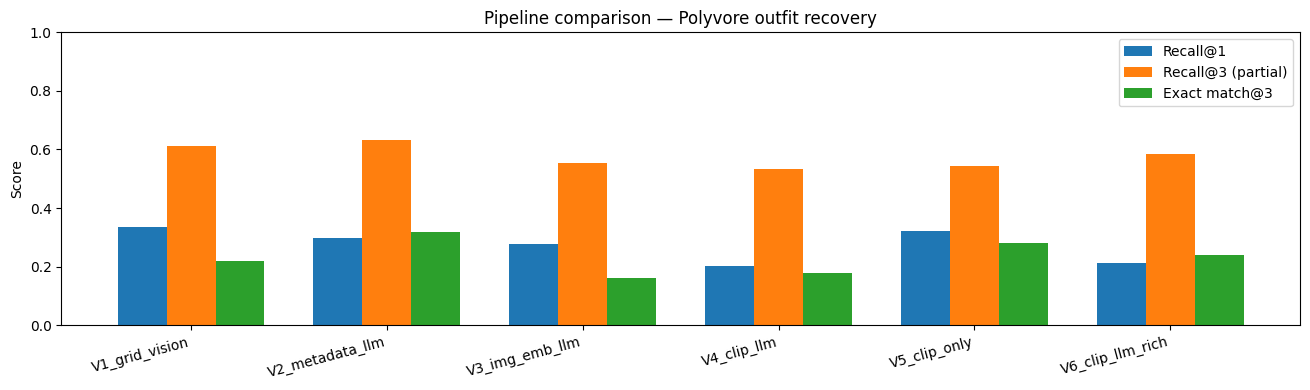

Chart saved to /Users/mohitjoshi/Projects/fashion-app/notebooks/eval_polyvore/results/comparison.png


In [43]:
def load_results() -> dict[str, list[dict]]:
    results = {}
    for path in sorted(RES_DIR.glob('*.jsonl')):
        rows = []
        with open(path) as f:
            for line in f:
                try:
                    rows.append(json.loads(line))
                except Exception:
                    pass
        if rows:
            results[path.stem] = rows
    return results

results = load_results()

# ── Summary table ──
print(f"{'Pipeline':<25}  {'N':>4}  {'R@1':>7}  {'R@3':>7}  {'Exact@3':>8}  {'Ret.Recall':>11}")
print('-' * 75)
summary = {}
for name, rows in results.items():
    n      = len(rows)
    r1     = np.mean([r['recall_at_1'] for r in rows])
    r3     = np.mean([r['recall_at_3'] for r in rows])
    exact  = np.mean([r['exact_at_3']  for r in rows])
    rr_vals = [r['retrieval_recall'] for r in rows if r.get('retrieval_recall') is not None]
    rr     = np.mean(rr_vals) if rr_vals else float('nan')
    summary[name] = {'n': n, 'r1': r1, 'r3': r3, 'exact3': exact, 'ret_recall': rr}
    rr_str = f'{rr:>11.3f}' if not np.isnan(rr) else f"{'n/a':>11}"
    print(f'{name:<25}  {n:>4}  {r1:>7.3f}  {r3:>7.3f}  {exact:>8.3f}  {rr_str}')

# ── Bar chart ──
names   = list(summary.keys())
r1s     = [summary[n]['r1']     for n in names]
r3s     = [summary[n]['r3']     for n in names]
exacts  = [summary[n]['exact3'] for n in names]

x   = np.arange(len(names))
w   = 0.25
fig, ax = plt.subplots(figsize=(max(7, len(names) * 2.2), 4))
ax.bar(x - w, r1s,    w, label='Recall@1')
ax.bar(x,     r3s,    w, label='Recall@3 (partial)')
ax.bar(x + w, exacts, w, label='Exact match@3')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Pipeline comparison — Polyvore outfit recovery')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(RES_DIR / 'comparison.png', dpi=150)
plt.show()
print(f'Chart saved to {RES_DIR}/comparison.png')

## 10b. Recompute metrics from saved recommendations

Run this any time you change the scoring functions — reads `recommendations` from the saved JSONL files and rewrites the metric columns in place. Never reruns the pipelines.

In [ ]:
def recompute_metrics():
    """
    Re-reads recommendations from all saved result JSONL files and rewrites
    metric columns (recall_at_1, recall_at_3, exact_at_3) using current scoring functions.
    Safe to run without touching pipeline results — only metric values change.
    """
    result_files = sorted(RES_DIR.glob('*.jsonl'))
    if not result_files:
        print('No result files found in', RES_DIR)
        return

    for path in result_files:
        rows = []
        with open(path) as f:
            for line in f:
                try:
                    rows.append(json.loads(line))
                except Exception:
                    pass
        if not rows:
            continue

        updated = []
        for row in rows:
            recs = row.get('recommendations', [])
            gt   = row.get('ground_truth', {})
            row['recall_at_1'] = recall_at_k(recs, gt, k=1)
            row['recall_at_3'] = recall_at_k(recs, gt, k=3)
            row['exact_at_3']  = exact_match_at_k(recs, gt, k=3)
            updated.append(row)

        with open(path, 'w') as f:
            for row in updated:
                f.write(json.dumps(row) + '\n')

        r1    = sum(r['recall_at_1'] for r in updated) / len(updated)
        r3    = sum(r['recall_at_3'] for r in updated) / len(updated)
        exact = sum(r['exact_at_3']  for r in updated) / len(updated)
        print(f'{path.stem:<25}  n={len(updated)}  R@1={r1:.3f}  R@3={r3:.3f}  Exact@3={exact:.3f}')

    print('\nDone. Re-run the results cell (10) to refresh charts.')

recompute_metrics()

In [ ]:
# ── Inspect failures for a specific pipeline ──
INSPECT_PIPELINE = 'V4_clip_llm'
SHOW_N           = 5

rows = results.get(INSPECT_PIPELINE, [])
failures = [r for r in rows if r['recall_at_3'] < 1.0]
print(f'{INSPECT_PIPELINE}: {len(failures)}/{len(rows)} not fully correct')

for row in failures[:SHOW_N]:
    print(f"\nset_id: {row['set_id']}")
    print(f"  ground truth:      {row['ground_truth']}")
    print(f"  top recommendation: {row['recommendations'][0] if row['recommendations'] else 'none'}")
    print(f"  recall@3: {row['recall_at_3']:.2f}")

    # Show images side by side: ground truth vs recommendation
    gt   = row['ground_truth']
    rec  = row['recommendations'][0] if row['recommendations'] else {}
    cats = sorted(set(gt) | set(rec))
    n    = len(cats)
    fig, axes = plt.subplots(2, n, figsize=(n * 2.2, 4.5))
    if n == 1: axes = [[axes[0]], [axes[1]]]
    for j, cat in enumerate(cats):
        for row_idx, (label, d) in enumerate([('GT', gt), ('Rec', rec)]):
            ax  = axes[row_idx][j]
            ax.axis('off')
            iid = d.get(cat)
            if iid:
                p = IMG_DIR / f'{iid}.jpg'
                if p.is_file():
                    ax.imshow(Image.open(p).convert('RGB'))
                ax.set_title(f'{label}\n{cat}\n{iid}', fontsize=7)
            else:
                ax.set_title(f'{label}\n{cat}\n—', fontsize=7)
    plt.tight_layout()
    plt.show()